# MCMC pour un modèle gaussien avec censure à droite

## Contexte

On suppose $X \sim \mathcal{N}(\theta, 1)$ et on dispose d'un échantillon $\mathbf{x_n}$ composé de :
- $n-1$ observations complètes $x_1, \ldots, x_{n-1}$ (iid)
- une **pseudo-observation censurée** $y$ : on sait seulement que la vraie observation $x_n > y$

## Vraisemblance

$$
f(\mathbf{x_n} | \theta) \;\propto\; \underbrace{\exp\left(-\frac{1}{2}\sum_{k=1}^{n-1}(x_k - \theta)^2\right)}_{\text{terme régulier}} \;\times\; \underbrace{1 - \Phi(y - \theta)}_{\text{terme de censure } = P(X > y)}
$$

## A priori

$$\theta \sim \mathcal{N}(\mu, 1)$$

## A posteriori

$$
\pi(\theta | \mathbf{x_n}) \;\propto\; \exp\left\{-\frac{n}{2}\left[\theta - \frac{1}{n}\left(\mu + \sum_{k=1}^{n-1} x_k\right)\right]^2\right\} \;\times\; \left\{1 - \Phi(y - \theta)\right\}
$$

Le terme de censure empêche d'obtenir une loi conjuguée → on utilise un **algorithme de Metropolis-Hastings**.

## 1. Imports

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from numpy.random import normal, uniform
from math import floor

## 2. Données

On génère un jeu de données synthétique :
- $n-1 = 9$ observations complètes tirées de $\mathcal{N}(\theta_{\text{vrai}}, 1)$
- 1 observation censurée $y$ : on connaît seulement un seuil $y$ tel que $x_n > y$
- A priori : $\theta \sim \mathcal{N}(\mu, 1)$ avec $\mu = 0$

In [2]:
np.random.seed(42)

# Paramètre vrai
theta_vrai = 2.0

# Observations complètes x_1, ..., x_{n-1}
n_complet = 9
x_obs = normal(loc=theta_vrai, scale=1.0, size=n_complet)

# Observation censurée : on sait que x_n > y
# On tire x_n puis on fixe y < x_n comme seuil de censure
x_n_latent = normal(loc=theta_vrai, scale=1.0)
y_censure = x_n_latent - 0.5  # seuil de censure (y < x_n)

# Taille totale de l'échantillon
n = n_complet + 1  # n-1 observations complètes + 1 censurée

# Hyperparamètre de l'a priori
mu_prior = 0.0

print(f"θ vrai = {theta_vrai}")
print(f"Observations complètes : {np.round(x_obs, 3)}")
print(f"Seuil de censure y = {y_censure:.3f}")
print(f"Moyenne des obs complètes : {np.mean(x_obs):.3f}")
print(f"n = {n} (dont 1 censurée)")

θ vrai = 2.0
Observations complètes : [2.497 1.862 2.648 3.523 1.766 1.766 3.579 2.767 1.531]
Seuil de censure y = 2.043
Moyenne des obs complètes : 2.438
n = 10 (dont 1 censurée)


## 3. Log-densité a posteriori (non normalisée)

La log-densité a posteriori s'écrit :

$$
\log \tilde{\pi}(\theta | \mathbf{x_n}) = -\frac{n}{2}\left[\theta - \frac{1}{n}\left(\mu + \sum_{k=1}^{n-1} x_k\right)\right]^2 + \log\left[1 - \Phi(y - \theta)\right]
$$

- Le premier terme est un noyau gaussien (a priori × vraisemblance des observations complètes)
- Le second terme vient de la censure : $P(X_n > y | \theta) = 1 - \Phi(y - \theta)$

In [3]:
def log_posterior(theta, x_obs, y, mu_prior, n):
    """
    Log-densité a posteriori non normalisée de theta.
    
    Paramètres
    ----------
    theta    : valeur du paramètre
    x_obs    : array des n-1 observations complètes
    y        : seuil de censure (on sait que x_n > y)
    mu_prior : moyenne de l'a priori N(mu, 1)
    n        : taille totale de l'échantillon (n-1 complet + 1 censuré)
    """
    # Centre du noyau gaussien
    center = (mu_prior + np.sum(x_obs)) / n
    
    # Terme gaussien (a priori + vraisemblance des obs complètes)
    log_gauss = - (n / 2) * (theta - center) ** 2
    
    # Terme de censure : log P(X_n > y | theta) = log(1 - Phi(y - theta))
    log_censure = norm.logsf(y - theta)  # logsf = log(1 - cdf), numériquement stable
    
    return log_gauss + log_censure

## 4. Loi instrumentale (proposition)

On utilise une **marche aléatoire gaussienne** comme loi instrumentale :

$$\theta^* \sim \mathcal{N}(\theta_{\text{courant}},\, \sigma_{\text{prop}}^2)$$

Le choix de $\sigma_{\text{prop}}$ contrôle le taux d'acceptation :
- trop petit → l'algorithme explore lentement (taux d'acceptation élevé mais autocorrélation forte)
- trop grand → beaucoup de rejets

In [4]:
def propose(theta_current, sigma_prop):
    """Tire une proposition depuis une marche aléatoire gaussienne."""
    return normal(loc=theta_current, scale=sigma_prop)

## 5. Étape de Metropolis-Hastings

À chaque itération :
1. On propose $\theta^* \sim q(\cdot | \theta_t) = \mathcal{N}(\theta_t, \sigma_{\text{prop}}^2)$
2. On calcule le **log-ratio d'acceptation** :
$$\log \alpha = \log \tilde{\pi}(\theta^* | \mathbf{x_n}) - \log \tilde{\pi}(\theta_t | \mathbf{x_n})$$
   (la loi instrumentale étant symétrique, les termes $q$ s'annulent)
3. On accepte $\theta^* $ avec probabilité $\min(1, \alpha)$

In [5]:
def metropolis_hastings_step(theta_current, sigma_prop, x_obs, y, mu_prior, n):
    """
    Une étape de Metropolis-Hastings avec marche aléatoire symétrique.
    
    Retourne (theta_nouveau, accepté : bool)
    """
    # 1. Proposition
    theta_star = propose(theta_current, sigma_prop)
    
    # 2. Log-ratio d'acceptation (q symétrique → les termes s'annulent)
    log_alpha = (log_posterior(theta_star, x_obs, y, mu_prior, n)
                 - log_posterior(theta_current, x_obs, y, mu_prior, n))
    
    # 3. Acceptation / rejet
    log_u = np.log(uniform())
    if log_u < log_alpha:
        return theta_star, True
    else:
        return theta_current, False

## 6. Diagnostic de convergence : statistique de Brooks-Gelman

On lance **plusieurs chaînes** en parallèle pour vérifier la convergence.  
La statistique de Brooks-Gelman compare la variabilité **intra-chaîne** à la variabilité **inter-chaîne**.

$$R = \frac{B}{W}$$

Si $R \approx 1$, les chaînes ont convergé vers la même distribution.

In [6]:
def brooks_gelman(theta_chains, prob=0.9):
    """
    Statistique de Brooks-Gelman basée sur les intervalles de crédibilité.
    
    Paramètres
    ----------
    theta_chains : array (N_iter, nb_chains)
    prob         : niveau de l'intervalle de crédibilité
    
    Retourne R = B / W
    """
    n_iter, nb_chains = theta_chains.shape
    q_low = (1 - prob) / 2
    q_high = 1 - q_low
    
    # Largeur moyenne des IC intra-chaîne
    W = np.mean([
        np.quantile(theta_chains[:, j], q_high) - np.quantile(theta_chains[:, j], q_low)
        for j in range(nb_chains)
    ])
    
    # Largeur de l'IC global (toutes chaînes confondues)
    all_samples = theta_chains.flatten()
    B = np.quantile(all_samples, q_high) - np.quantile(all_samples, q_low)
    
    if W == 0:
        return np.inf
    return B / W

## 7. Boucle MCMC complète (multi-chaînes)

On lance `nb_chains` chaînes indépendantes initialisées à des valeurs différentes.  
Chaque chaîne effectue `burn_in + N` itérations de Metropolis-Hastings.  
On ne conserve que les `N` dernières itérations (après la **période de chauffe**).

In [7]:
def run_mcmc(x_obs, y, mu_prior, n, sigma_prop=0.5,
             N=5000, burn_in=2000, nb_chains=3, bg_every=100):
    """
    Algorithme de Metropolis-Hastings pour le modèle gaussien censuré.
    
    Paramètres
    ----------
    x_obs      : observations complètes (array)
    y          : seuil de censure
    mu_prior   : moyenne de l'a priori N(mu, 1)
    n          : taille totale de l'échantillon
    sigma_prop : écart-type de la loi instrumentale (marche aléatoire)
    N          : nombre d'itérations post burn-in
    burn_in    : nombre d'itérations de chauffe
    nb_chains  : nombre de chaînes parallèles
    bg_every   : fréquence de calcul de la statistique de Brooks-Gelman
    
    Retourne
    --------
    dict avec les échantillons post burn-in et les diagnostics
    """
    total = burn_in + N
    
    # Initialisation des chaînes à des valeurs dispersées
    theta_current = normal(loc=np.mean(x_obs), scale=2.0, size=nb_chains)
    
    # Stockage
    theta_samples = np.zeros((total, nb_chains))
    accept_count = np.zeros(nb_chains)
    bg_values = []
    bg_iterations = []
    
    for i in range(total):
        for j in range(nb_chains):
            theta_current[j], accepted = metropolis_hastings_step(
                theta_current[j], sigma_prop, x_obs, y, mu_prior, n
            )
            theta_samples[i, j] = theta_current[j]
            if accepted:
                accept_count[j] += 1
        
        # Diagnostic de Brooks-Gelman
        if (i + 1) % bg_every == 0 and i > 1:
            bg_val = brooks_gelman(theta_samples[:i+1, :])
            bg_values.append(bg_val)
            bg_iterations.append(i + 1)
    
    # Taux d'acceptation par chaîne
    accept_rates = accept_count / total
    
    print(f"Taux d'acceptation par chaîne : {np.round(accept_rates, 3)}")
    print(f"Taux d'acceptation moyen : {np.mean(accept_rates):.3f}")
    
    return {
        "samples": theta_samples[burn_in:, :],
        "all_samples": theta_samples,
        "bg_values": bg_values,
        "bg_iterations": bg_iterations,
        "accept_rates": accept_rates,
        "burn_in": burn_in
    }

## 8. Graphiques de diagnostic

On trace :
1. **Traces** des chaînes (pour visualiser la convergence et le mélange)
2. **Histogrammes** de la loi a posteriori (après burn-in)
3. **Statistique de Brooks-Gelman** au fil des itérations (doit tendre vers 1)

In [8]:
def plot_diagnostics(results, theta_vrai=None):
    """Trace les graphiques de diagnostic MCMC."""
    samples = results["samples"]
    all_samples = results["all_samples"]
    bg_values = results["bg_values"]
    bg_iters = results["bg_iterations"]
    burn_in = results["burn_in"]
    nb_chains = samples.shape[1]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1. Trace des chaînes
    for j in range(nb_chains):
        axes[0].plot(all_samples[:, j], alpha=0.6, linewidth=0.5, label=f"Chaîne {j+1}")
    axes[0].axvline(x=burn_in, color='r', linestyle='--', label='Fin burn-in')
    if theta_vrai is not None:
        axes[0].axhline(y=theta_vrai, color='k', linestyle=':', label=f'θ vrai = {theta_vrai}')
    axes[0].set_title("Trace des chaînes")
    axes[0].set_xlabel("Itération")
    axes[0].set_ylabel("θ")
    axes[0].legend(fontsize=7)
    
    # 2. Histogramme a posteriori
    for j in range(nb_chains):
        axes[1].hist(samples[:, j], bins=50, alpha=0.5, density=True, label=f"Chaîne {j+1}")
    if theta_vrai is not None:
        axes[1].axvline(x=theta_vrai, color='k', linestyle=':', label=f'θ vrai = {theta_vrai}')
    axes[1].set_title("Histogramme a posteriori de θ")
    axes[1].set_xlabel("θ")
    axes[1].legend(fontsize=7)
    
    # 3. Brooks-Gelman
    axes[2].plot(bg_iters, bg_values, 'o-', markersize=3)
    axes[2].axhline(y=1, color='r', linestyle='--')
    axes[2].set_title("Statistique de Brooks-Gelman")
    axes[2].set_xlabel("Itération")
    axes[2].set_ylabel("R")
    
    plt.tight_layout()
    plt.show()

## 9. Exécution

On lance la MCMC avec $\sigma_{\text{prop}} = 0.5$, 3 chaînes, 2000 itérations de burn-in et 5000 itérations utiles.

Taux d'acceptation par chaîne : [0.568 0.565 0.573]
Taux d'acceptation moyen : 0.568


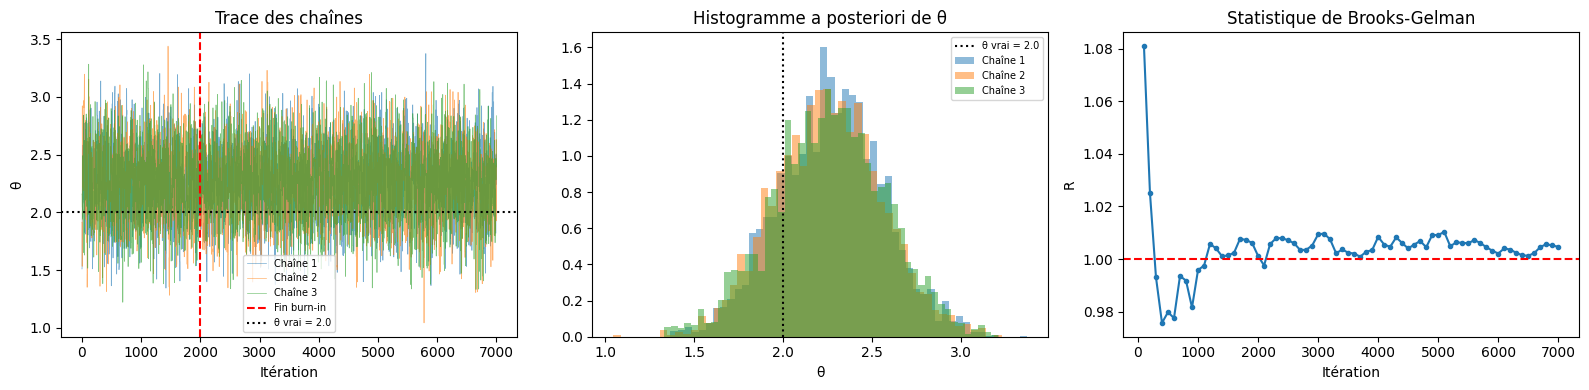

In [9]:
results = run_mcmc(
    x_obs=x_obs, y=y_censure, mu_prior=mu_prior, n=n,
    sigma_prop=0.5, N=5000, burn_in=2000, nb_chains=3, bg_every=100
)

plot_diagnostics(results, theta_vrai=theta_vrai)

## 10. Résumé a posteriori

Statistiques de synthèse de l'échantillon a posteriori : moyenne, médiane, écart-type, intervalle de crédibilité à 95%.

In [10]:
all_post = results["samples"].flatten()

print("=== Résumé a posteriori de θ ===")
print(f"  Moyenne        : {np.mean(all_post):.4f}")
print(f"  Médiane        : {np.median(all_post):.4f}")
print(f"  Écart-type     : {np.std(all_post):.4f}")
print(f"  IC 95%         : [{np.quantile(all_post, 0.025):.4f}, {np.quantile(all_post, 0.975):.4f}]")
print(f"  θ vrai         : {theta_vrai}")

# Comparaison avec le cas sans censure (a posteriori conjugué exact)
center_no_censure = (mu_prior + np.sum(x_obs)) / n
var_no_censure = 1 / n
print(f"\n=== Référence : a posteriori sans censure (gaussien conjugué) ===")
print(f"  Moyenne        : {center_no_censure:.4f}")
print(f"  Écart-type     : {np.sqrt(var_no_censure):.4f}")

=== Résumé a posteriori de θ ===
  Moyenne        : 2.2623
  Médiane        : 2.2655
  Écart-type     : 0.3031
  IC 95%         : [1.6730, 2.8629]
  θ vrai         : 2.0

=== Référence : a posteriori sans censure (gaussien conjugué) ===
  Moyenne        : 2.1938
  Écart-type     : 0.3162


## 11. Comparaison visuelle : a posteriori censuré vs non censuré

On superpose la densité a posteriori estimée par MCMC (cas censuré) avec la loi a posteriori exacte du cas non censuré $\mathcal{N}\left(\frac{\mu + \sum x_k}{n}, \frac{1}{n}\right)$ pour visualiser l'effet de la censure.

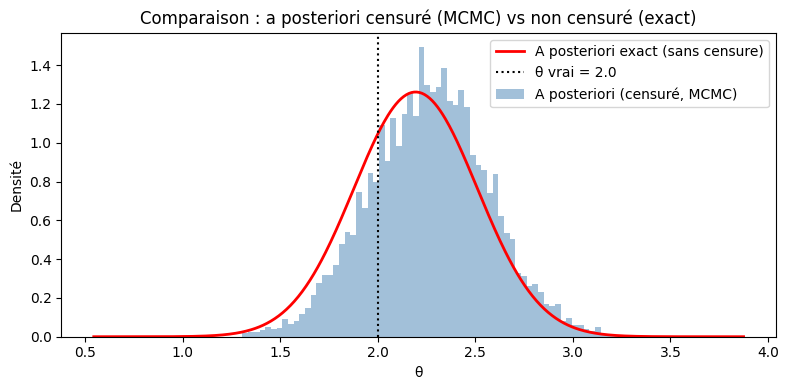

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

# Histogramme MCMC (censuré)
ax.hist(all_post, bins=80, density=True, alpha=0.5, color='steelblue', label='A posteriori (censuré, MCMC)')

# A posteriori exact sans censure : N(center, 1/n)
theta_grid = np.linspace(all_post.min() - 0.5, all_post.max() + 0.5, 500)
pdf_no_censure = norm.pdf(theta_grid, loc=center_no_censure, scale=np.sqrt(var_no_censure))
ax.plot(theta_grid, pdf_no_censure, 'r-', linewidth=2, label='A posteriori exact (sans censure)')

# Theta vrai
ax.axvline(x=theta_vrai, color='k', linestyle=':', linewidth=1.5, label=f'θ vrai = {theta_vrai}')

ax.set_xlabel("θ")
ax.set_ylabel("Densité")
ax.set_title("Comparaison : a posteriori censuré (MCMC) vs non censuré (exact)")
ax.legend()
plt.tight_layout()
plt.show()